In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [ ]:
# load dataset path
original_dir = "/content/drive/MyDrive/AI and ML/coursework/flowers"
base_dir     = "/content/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

#
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

In [ ]:

classes = os.listdir(original_dir)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['sunflower', 'rose', 'daisy', 'dandelion', 'tulip']
Number of classes: 5


In [ ]:
#Total number of images

total_images = 0
class_counts = {}

for cls in classes:
    total_images += len(os.listdir(os.path.join(original_dir, cls)))
    class_path = os.path.join(original_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))


print("Total images in dataset:", total_images)
print(class_counts)

Total images in dataset: 4346
{'sunflower': 733, 'rose': 810, 'daisy': 765, 'dandelion': 1054, 'tulip': 984}


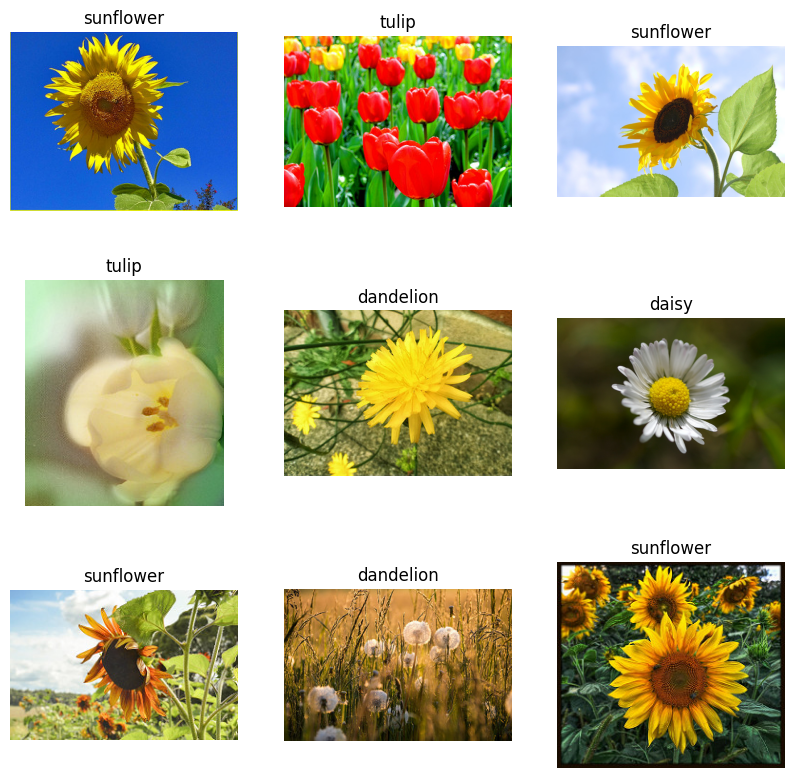

In [ ]:
#Show sample images

plt.figure(figsize=(10,10))

for i in range(9):
    cls = random.choice(classes)
    img_path = os.path.join(original_dir, cls, random.choice(os.listdir(os.path.join(original_dir, cls))))

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

##Check for Courrupted Images

In [ ]:
#check for the corrupted images
corrupted_images = []  # List to store corrupted image paths

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print(f"\n  Corrupted Images Found: {len(corrupted_images)}")
    for img in corrupted_images:
        print(f"   Removing: {img}")
        os.remove(img)
    print(" Corrupted images removed.")
else:
    print("\n No corrupted images found.")


 No corrupted images found.


##Check Class Balance

###A balanced dataset ensures no class dominates the model. If some classes have significantly more images, the model become biased towards those classes.

In [ ]:
# Dictionary to store class counts
class_counts = {}

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print Class Distribution
total = sum(class_counts.values())

print("\nClass Distribution:")
print("=" * 55)
print(f"{'Class Name':<20} {'Image Count':>12} {'Percentage':>12}")
print("=" * 55)
for class_name, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{class_name:<20} {count:>12} {pct:>11.1f}%")
print("=" * 55)
print(f"{'TOTAL':<20} {total:>12} {'100.0%':>12}")


Class Distribution:
Class Name            Image Count   Percentage
sunflower                     733        16.9%
rose                          810        18.6%
daisy                         765        17.6%
dandelion                    1054        24.3%
tulip                         984        22.6%
TOTAL                        4346       100.0%


In my dataset there is not a severe imbalance, so it doesnot require correction.

##Visualize Class Distribution

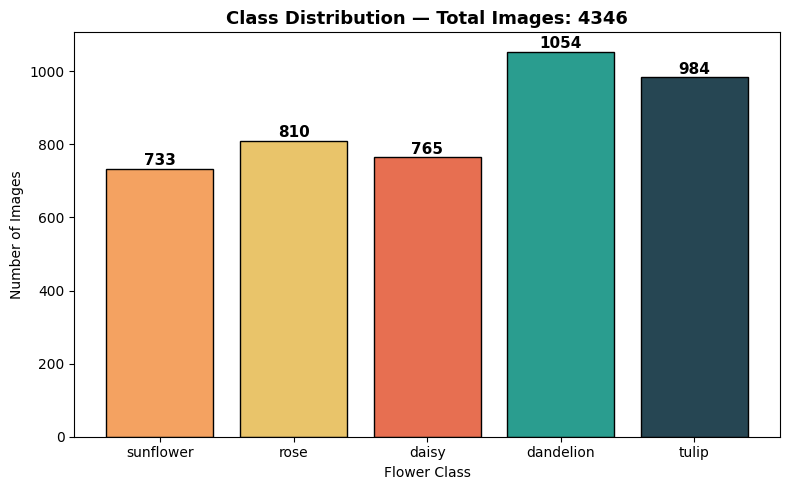

In [ ]:
colors = ["#f4a261", "#e9c46a", "#e76f51", "#2a9d8f", "#264653"]
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=colors, edgecolor='black')

for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             str(count), ha='center', fontsize=11, fontweight='bold')

plt.title(f"Class Distribution — Total Images: {total}", fontsize=13, fontweight='bold')
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

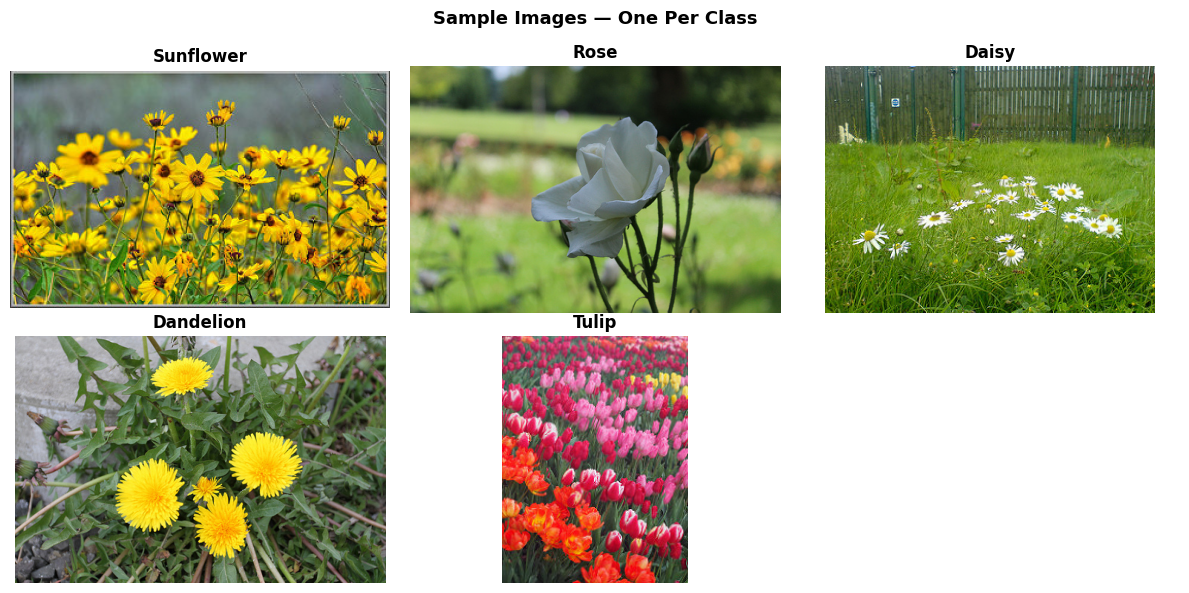

In [ ]:
selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in classes:
    class_path = os.path.join(original_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Plot in grid
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i].capitalize(), fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.suptitle("Sample Images — One Per Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Split Dataset - Trian, Validation adn Test

In [ ]:
import os
import shutil
import random

# # Force a clean split every time this cell is run.
# # If base_dir exists, remove it and its contents.
# if os.path.exists(base_dir):
#     print(" Removing existing split directory to perform a clean split...")
#     shutil.rmtree(base_dir)

# print("Creating split folders...")

# # Create base directory and subdirectories for train, val, test
# os.makedirs(train_dir, exist_ok=True)
# os.makedirs(val_dir, exist_ok=True)
# os.makedirs(test_dir, exist_ok=True)

# # Iterate through each original class folder
# for cls in classes: # Use 'classes' (globally defined) instead of 'class_names' (defined after split)
#     cls_path = os.path.join(original_dir, cls)
#     if os.path.isdir(cls_path):
#         images = [f for f in os.listdir(cls_path)
#                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
#         random.shuffle(images)

#         total_cls  = len(images)
#         train_end  = int(0.70 * total_cls)
#         val_end    = int(0.85 * total_cls)

#         for i, img in enumerate(images):
#             src = os.path.join(cls_path, img)
#             if i < train_end:
#                 dst_dir = os.path.join(train_dir, cls)
#             elif i < val_end:
#                 dst_dir = os.path.join(val_dir, cls)
#             else:
#                 dst_dir = os.path.join(test_dir, cls)

#             os.makedirs(dst_dir, exist_ok=True)
#             shutil.copy(src, os.path.join(dst_dir, img))

# print(" Dataset split complete!")

# # ── Print split summary ──
# print("\nSplit Summary:")
# print("=" * 40)
# print(f"{'Split':<15} {'Images':>10} {'%':>8}")
# print("=" * 40)

# # Recalculate total from original_dir to get correct percentages
# # Use the 'class_counts' dictionary that was populated earlier for the original_dir
# total_original_images = sum(class_counts.values())

# for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
#     count = 0
#     if os.path.exists(split_dir):
#         for cls_sub_dir in os.listdir(split_dir):
#             full_cls_path = os.path.join(split_dir, cls_sub_dir)
#             if os.path.isdir(full_cls_path):
#                 count += len(os.listdir(full_cls_path))

#     # Only calculate percentage if total_original_images is not zero to avoid division by zero
#     pct = (count / total_original_images * 100) if total_original_images > 0 else 0.0
#     print(f"{split_name:<15} {count:>10}  {pct:>6.1f}%")
# print("=" * 40)

Creating split folders...
 Dataset split complete!

Split Summary:
Split               Images        %
Train                 3040    69.9%
Validation             652    15.0%
Test                   654    15.0%


In [ ]:
# ── Only split if not already done ──
if os.path.exists(base_dir) and len(os.listdir(base_dir)) > 0:
    print(" Split already exists — skipping to avoid duplicates.")
else:
    print(" Creating split folders...")

    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(folder, exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(original_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            random.shuffle(images)

            total_cls  = len(images)
            train_end  = int(0.70 * total_cls)
            val_end    = int(0.85 * total_cls)

            for i, img in enumerate(images):
                src = os.path.join(cls_path, img)
                if i < train_end:
                    dst_dir = os.path.join(train_dir, cls)
                elif i < val_end:
                    dst_dir = os.path.join(val_dir, cls)
                else:
                    dst_dir = os.path.join(test_dir, cls)

                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy(src, os.path.join(dst_dir, img))

    print(" Dataset split complete!")

# ── Print split summary ──
print("\nSplit Summary:")
print("=" * 40)
print(f"{'Split':<15} {'Images':>10} {'%':>8}")
print("=" * 40)
for split_name, split_dir in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    count = sum(
        len(os.listdir(os.path.join(split_dir, cls)))
        for cls in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, cls))
    )
    print(f"{split_name:<15} {count:>10}  {count/total*100:>6.1f}%")
print("=" * 40)

 Split already exists — skipping to avoid duplicates.

Split Summary:
Split               Images        %
Train                 3040    69.9%
Validation             652    15.0%
Test                   654    15.0%


##Check Class Imbalance After Split

In [ ]:
# Update class_names from train_dir after split
class_names = sorted(os.listdir(train_dir))

# Count per class in train
class_counts_train = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts_train[class_name] = len(images)

train_total = sum(class_counts_train.values())

print("\nClass Distribution (Train Set):")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts_train.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution (Train Set):
Class Name               Valid Image Count
daisy                                535
dandelion                            737
rose                                 567
sunflower                            513
tulip                                688


##Data Augmentation

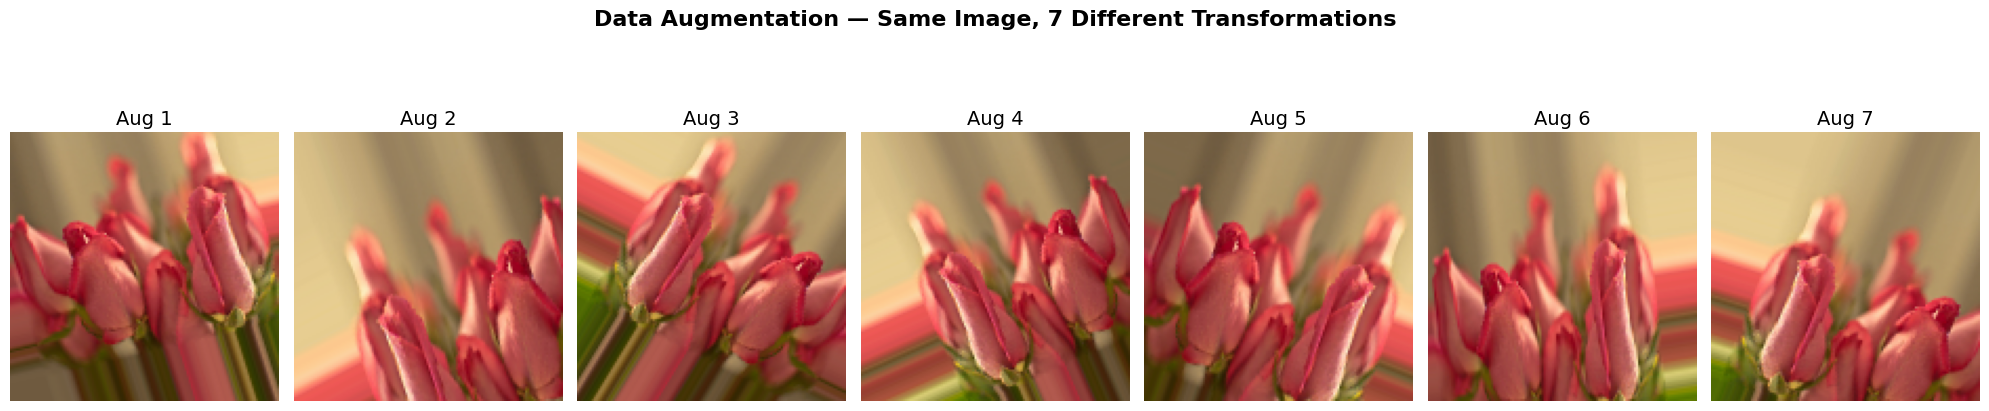

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,       # Rotate images by up to 30 degrees
    width_shift_range=0.2,   # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom in/out by 20%
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill in missing pixels
)

# Load one sample image from train/rose
rose_dir        = os.path.join(train_dir, "rose")
sample_img_name = random.choice(os.listdir(rose_dir))
sample_img_path = os.path.join(rose_dir, sample_img_name)

img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x   = image.img_to_array(img)
x   = np.expand_dims(x, axis=0)

# Generate and visualize 7 augmented images
aug_iter = datagen.flow(x, batch_size=1)

fig, axes = plt.subplots(1, 7, figsize=(20, 5))
fig.suptitle("Data Augmentation — Same Image, 7 Different Transformations",
             fontsize=16, fontweight='bold')

for i in range(7):
    batch = next(aug_iter)
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f"Aug {i+1}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


##Create ImageDataGenerator for Training

In [ ]:
# ── Training Generator: Augmentation + Normalization ──
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test Generators: Normalization ONLY ──
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3040 images belonging to 5 classes.
Found 652 images belonging to 5 classes.
Found 654 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


#Build the Baseline CNN Model

The baseline model follows this structure:
- **3 × Convolutional layers** — each followed by a MaxPooling layer
- **3 × Fully Connected (Dense) layers**
- **1 × Output layer** with softmax activation for 5-class classification

We use **ReLU** activation for all hidden layers as it is computationally efficient and avoids the vanishing gradient problem.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation, Dropout

NUM_CLASSES = len(class_names)

#  Baseline CNN Model
baseline_model = Sequential([

    #  Convolutional Block 1
    # 32 filters, 3x3 kernel, ReLU activation
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    # Convolutional Block 2
    # 64 filters — more filters to learn more complex features
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Convolutional Block 3
    # 128 filters — deeper features
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    #Flatten
    # Convert 3D feature maps to 1D vector
    Flatten(),

    # ── Fully Connected Layers ──
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),

    # ── Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

print(" Baseline model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 Baseline model built successfully!


In [ ]:
#Model Summary

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

##Compiling the Baseline Model

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")

 Model compiled successfully!


##Train the Model

###We use the Earlystopping to prent from the overfitting and saves training time.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if val_loss does not improve for 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

import time
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

baseline_training_time = time.time() - start_time
print(f"\nTraining time: {baseline_training_time:.2f} seconds")

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.3589 - loss: 1.4148 - val_accuracy: 0.5322 - val_loss: 1.1376
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.5273 - loss: 1.1177 - val_accuracy: 0.4755 - val_loss: 1.2723
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5664 - loss: 1.0680 - val_accuracy: 0.6135 - val_loss: 0.9915
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6033 - loss: 0.9934 - val_accuracy: 0.6196 - val_loss: 0.9984
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.6286 - loss: 0.9488 - val_accuracy: 0.6549 - val_loss: 0.9085
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.6451 - loss: 0.8925 - val_accuracy: 0.6426 - val_loss: 0.9117
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6641 - loss: 0.8650 - val_accuracy: 0.6564 - val_loss: 0.9169
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.6635 - loss: 0.8514 - val_accuracy: 0.6518 - v

##Plot Traiing vs Validation Loss and Accuracy

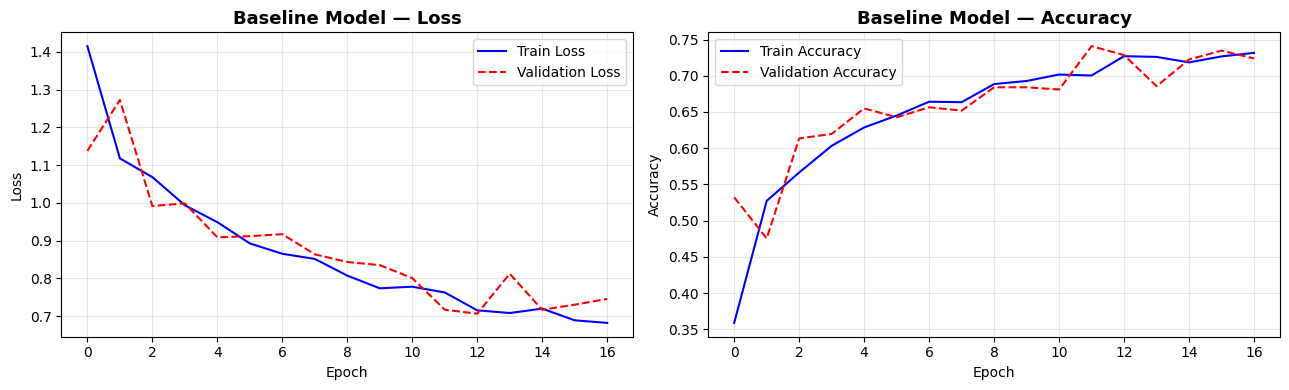

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss ──
axes[0].plot(baseline_history.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(baseline_history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
axes[0].set_title('Baseline Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(baseline_history.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(baseline_history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[1].set_title('Baseline Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


##Evaluate the Model on Test Set

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("\n" + "=" * 40)
print(f"  Baseline Model — Test Results")
print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 40)

21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 400ms/step - accuracy: 0.7401 - loss: 0.7146

  Baseline Model — Test Results
  Test Loss     : 0.7146
  Test Accuracy : 74.01%


##Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Get true labels and predictions
test_generator.reset()
predictions    = baseline_model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 829ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.81      0.69      0.75       115
   dandelion       0.86      0.77      0.81       159
        rose       0.59      0.74      0.66       122
   sunflower       0.80      0.82      0.81       110
       tulip       0.68      0.70      0.69       148

    accuracy                           0.74       654
   macro avg       0.75      0.74      0.74       654
weighted avg       0.75      0.74      0.74       654



##Confusion Matrix

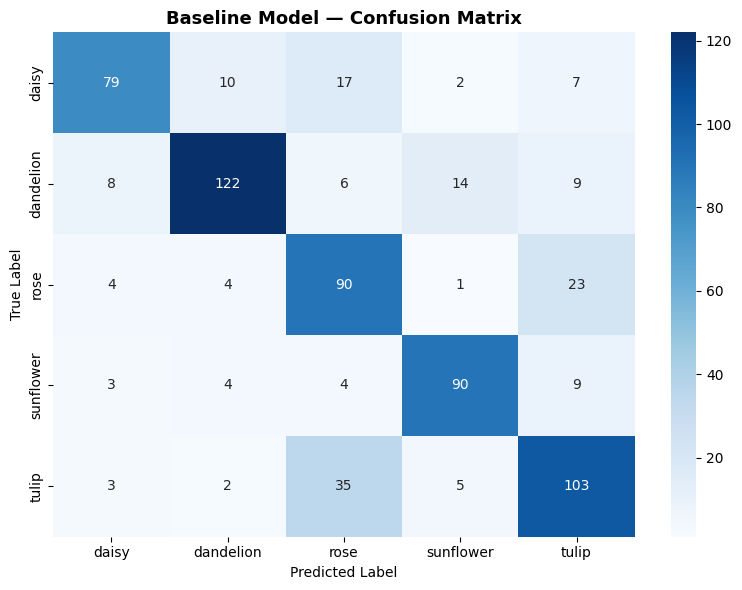

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


##Intference on Sample Images

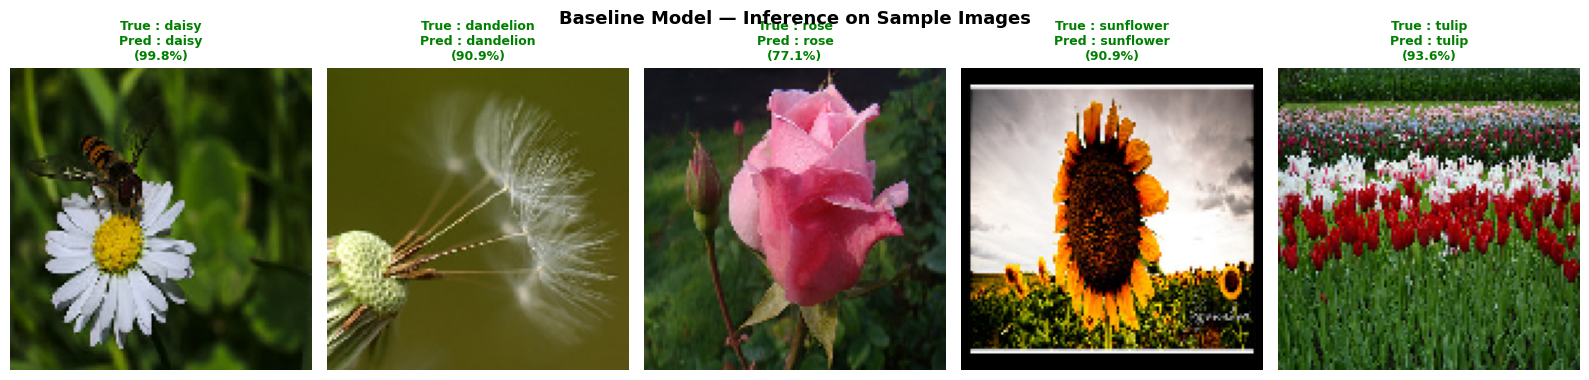


Green title = Correct prediction
   Red title   = Wrong prediction


In [ ]:
import random
from tensorflow.keras.preprocessing import image as keras_image

# Pick 5 random images from test set
sample_images = []
sample_labels = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    images     = os.listdir(class_path)
    img_name   = random.choice(images)
    sample_images.append(os.path.join(class_path, img_name))
    sample_labels.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Baseline Model — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    # Load and preprocess
    img      = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr  = keras_image.img_to_array(img) / 255.0
    img_arr  = np.expand_dims(img_arr, axis=0)

    # Predict
    pred        = baseline_model.predict(img_arr, verbose=0)
    pred_label  = class_names[np.argmax(pred)]
    confidence  = np.max(pred) * 100

    # Plot
    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')

    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("baseline_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nGreen title = Correct prediction")
print("   Red title   = Wrong prediction")

##Save the Baseline CNN model

In [ ]:
baseline_model.save("baseline_model.h5")
print("Baseline model saved as baseline_model.h5")

Baseline model saved as baseline_model.h5


#Build the Deeper CNN Model

Compared to the baseline (3 conv layers), this model has **6 convolutional layers** — double the depth.

Two new techniques are added:

**BatchNormalization:**
- Normalizes the output of each layer during training
- Helps the model train faster and more stably
- Reduces sensitivity to weight initialization

**Dropout:**
- Randomly switches off a fraction of neurons during training
- Prevents the model from memorizing training data (overfitting)
- `Dropout(0.25)` = 25% of neurons are switched off per step

In [ ]:
def build_deeper_model(optimizer):
    """
    Builds and compiles the deeper CNN model.
    optimizer: pass 'adam' or SGD() object
    """
    model = Sequential([

        # ── Conv Block 1 ── (32 filters)
        Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 2 ── (64 filters)
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 3 ── (128 filters)
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 4 ── (256 filters)
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 5 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # ── Conv Block 6 ── (512 filters)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.25),

        # ── Flatten ──
        Flatten(),

        # ── Fully Connected Layers ──
        Dense(512),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # ── Output Layer ──
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_deeper_model() function defined.")

build_deeper_model() function defined.


##Compile the MOdel

#Model Summary

Compare the total parameters with baseline model - deeper model will have siginificantly more.

In [ ]:
# Print summary using Adam (architecture is same regardless of optimizer)
temp_model = build_deeper_model('adam')
temp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,297,669 (31.65 MB)

 Trainable params: 8,292,869 (31.63 MB)

 Non-trainable params: 4,800 (18.75 KB)

##Train the Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import time

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Build with Adam
model_adam = build_deeper_model(optimizer=Adam(learning_rate=0.001))

print("Training Deeper Model with ADAM...")
start_adam = time.time()

history_adam = model_adam.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_adam = time.time() - start_adam
print(f"\n Adam Training Time: {time_adam:.2f} seconds")

Training Deeper Model with ADAM...
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.3148 - loss: 1.7245 - val_accuracy: 0.2423 - val_loss: 3.7641
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.4480 - loss: 1.3827 - val_accuracy: 0.2423 - val_loss: 4.3827
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.4954 - loss: 1.2452 - val_accuracy: 0.2423 - val_loss: 5.3051
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.5365 - loss: 1.1508 - val_accuracy: 0.2745 - val_loss: 2.8025
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.5681 - loss: 1.0974 - val_accuracy: 0.2515 - val_loss: 3.0258
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.5938 - loss: 1.0325 - val_accuracy: 0.4356 - val_loss: 1.5063
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.5964 - loss: 1.0221 - val_accuracy: 0.6058 - val_loss: 1.1645
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.6148 - loss

##Adam Plot Trainign vs Vlidation Loss and Accuracy

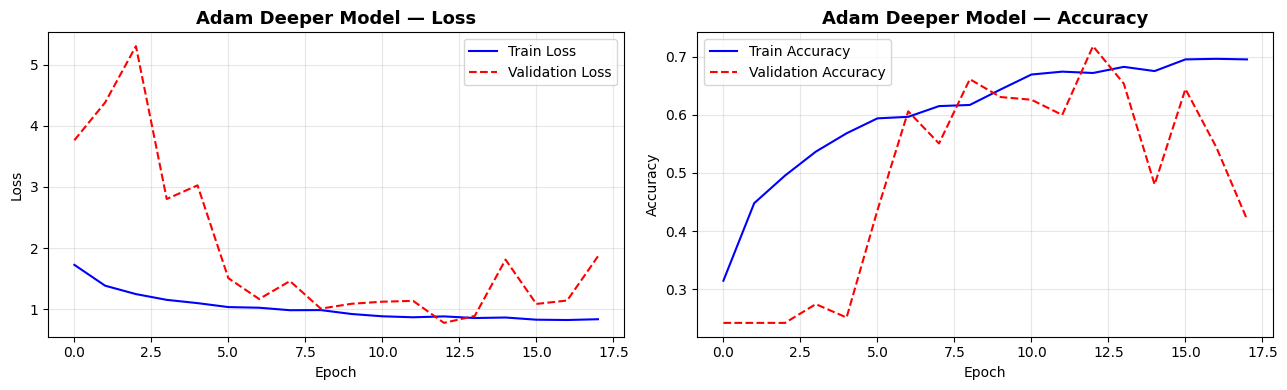

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_adam.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_adam.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
axes[0].set_title('Adam Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_adam.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history_adam.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[1].set_title('Adam Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


#Train Deepr Model with SGD Optimizer

In [ ]:
from tensorflow.keras.optimizers import SGD

# Build with SG
model_sgd = build_deeper_model(
    optimizer=SGD(learning_rate=0.001, momentum=0.9)
)

print("Training Deeper Model with SGD...")
start_sgd = time.time()

history_sgd = model_sgd.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_sgd = time.time() - start_sgd
print(f"\n SGD Training Time: {time_sgd:.2f} seconds")

Training Deeper Model with SGD...
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.2303 - loss: 2.0113 - val_accuracy: 0.2423 - val_loss: 1.6656
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.2760 - loss: 1.7655 - val_accuracy: 0.2423 - val_loss: 1.7625
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.3102 - loss: 1.6281 - val_accuracy: 0.2423 - val_loss: 1.8398
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.3503 - loss: 1.5428 - val_accuracy: 0.2423 - val_loss: 1.9903
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 333s 4s/step - accuracy: 0.3750 - loss: 1.4485 - val_accuracy: 0.2546 - val_loss: 2.0453

 SGD Training Time: 1669.88 seconds


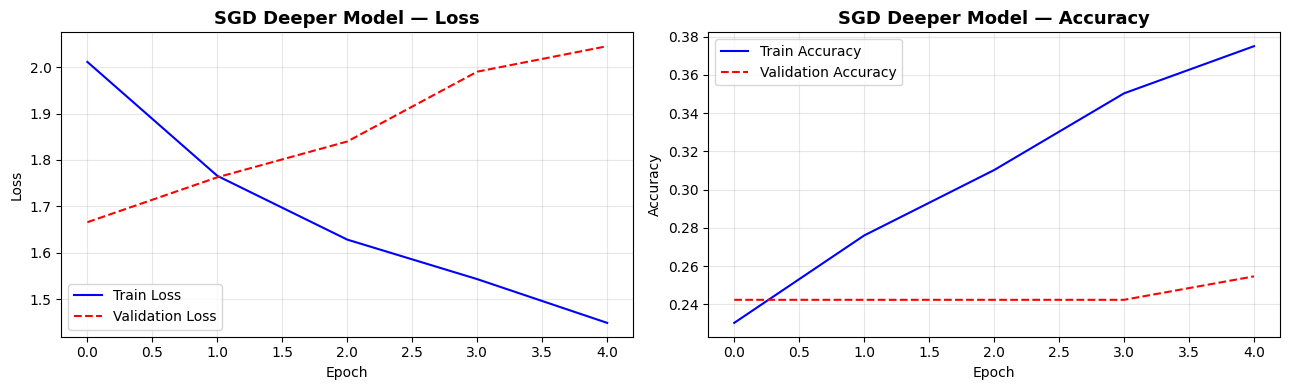

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history_sgd.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_sgd.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
axes[0].set_title('SGD Deeper Model — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_sgd.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history_sgd.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[1].set_title('SGD Deeper Model — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("deeper_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


##Compare Performance of Adam vs SGD - Training Curves

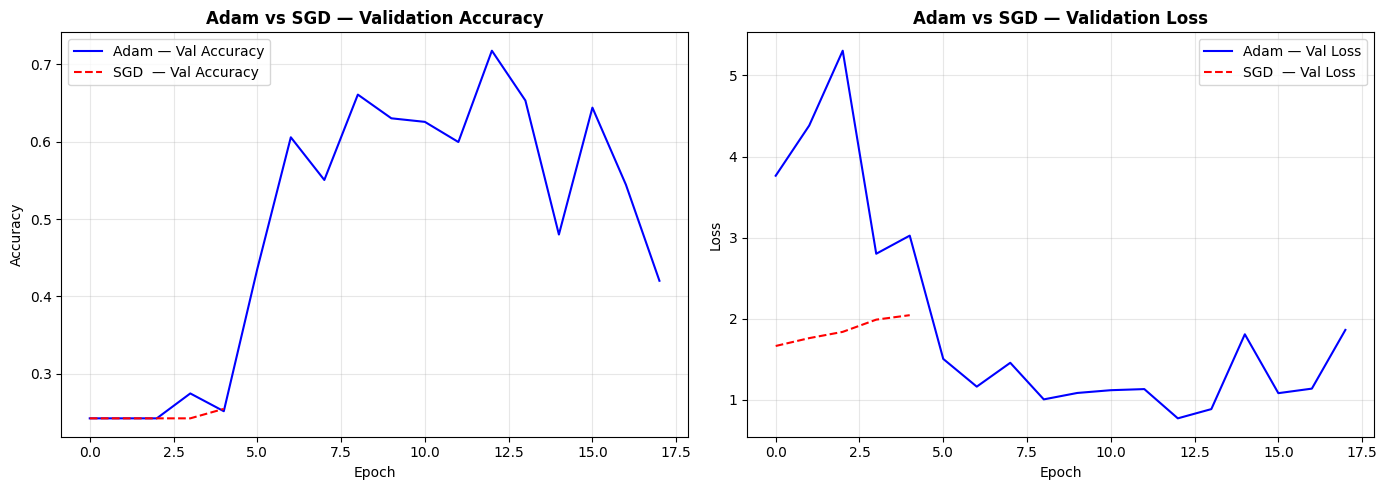

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['val_accuracy'],
             label='Adam — Val Accuracy', color='blue')
axes[0].plot(history_sgd.history['val_accuracy'],
             label='SGD  — Val Accuracy', color='red', linestyle='--')
axes[0].set_title('Adam vs SGD — Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['val_loss'],
             label='Adam — Val Loss', color='blue')
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD  — Val Loss', color='red', linestyle='--')
axes[1].set_title('Adam vs SGD — Validation Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("adam_vs_sgd.png", dpi=150, bbox_inches='tight')
plt.show()


SGD stopped earlier than Adam because it uses a fixed learning rate for all weights throughout training, causing the validation loss to fluctuate up and down in the early epochs while the optimizer was still finding the right direction. This instability caused the EarlyStopping patience counter to reach its limit of 5 quickly, terminating training prematurely. Adam on the other hand automatically adjusts the learning rate individually for each weight based on past gradients, allowing it to find the correct direction from the very first epoch and produce a consistently decreasing validation loss. This meant EarlyStopping's patience counter kept resetting to zero, allowing Adam to train for the full 24 epochs and achieve significantly better results

##Evaluate both optimizer on Test Set

In [ ]:


loss_adam, acc_adam = model_adam.evaluate(test_generator, verbose=0)
loss_sgd,  acc_sgd  = model_sgd.evaluate(test_generator,  verbose=0)

print("=" * 50)
print(f"{'Metric':<20} {'Adam':>12} {'SGD':>12}")
print("=" * 50)
print(f"{'Test Accuracy':<20} {acc_adam*100:>11.2f}% {acc_sgd*100:>11.2f}%")
print(f"{'Test Loss':<20} {loss_adam:>12.4f} {loss_sgd:>12.4f}")
print(f"{'Training Time (s)':<20} {time_adam:>12.2f} {time_sgd:>12.2f}")
print("=" * 50)

Metric                       Adam          SGD
Test Accuracy              70.95%       24.31%
Test Loss                  0.7597       1.6643
Training Time (s)         6052.26      1669.88


##Comparision between Baseline vs Deeper Model(Adam)

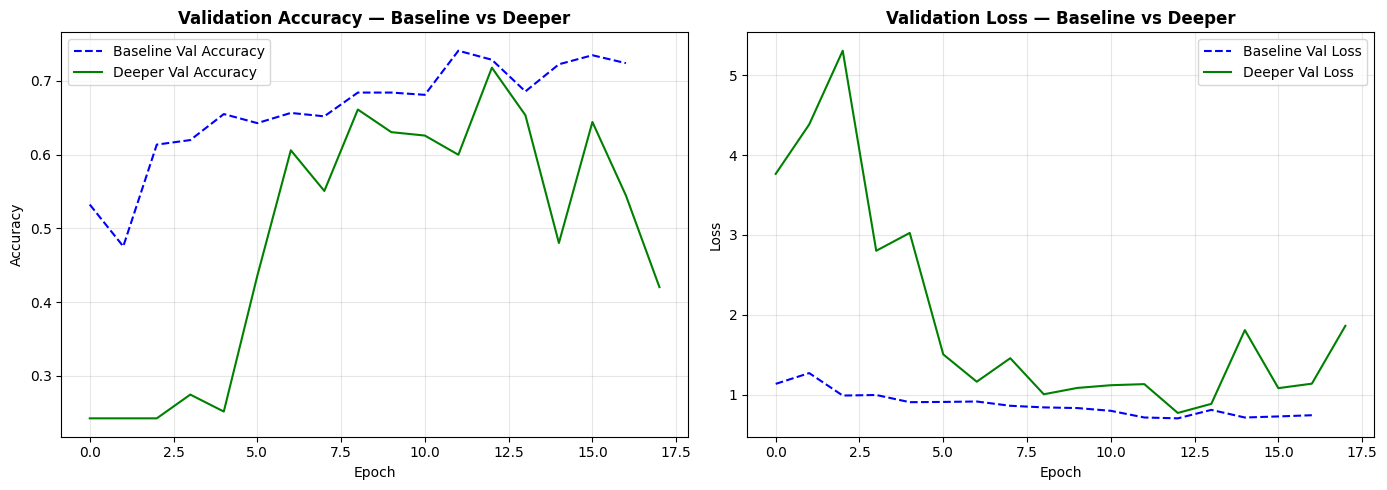

In [ ]:
# ── Load baseline history (must have run Stage 2 first) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Comparison ──
axes[0].plot(baseline_history.history['val_accuracy'],
             label='Baseline Val Accuracy', color='blue', linestyle='--')
axes[0].plot(history_adam.history['val_accuracy'],
             label='Deeper Val Accuracy',   color='green')
axes[0].set_title('Validation Accuracy — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss Comparison ──
axes[1].plot(baseline_history.history['val_loss'],
             label='Baseline Val Loss', color='blue', linestyle='--')
axes[1].plot(history_adam.history['val_loss'],
             label='Deeper Val Loss',   color='green')
axes[1].set_title('Validation Loss — Baseline vs Deeper', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_vs_deeper.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Get baseline results (from Stage 2) ──
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=0)
loss_adam,   acc_adam   = model_adam.evaluate(test_generator,   verbose=0)

print("=" * 55)
print(f"{'Metric':<25} {'Baseline':>12} {'Deeper':>12}")
print("=" * 55)
print(f"{'Test Accuracy':<25} {baseline_test_acc*100:>11.2f}% {acc_adam*100:>11.2f}%")
print(f"{'Test Loss':<25} {baseline_test_loss:>12.4f} {loss_adam:>12.4f}")
print(f"{'Training Time (s)':<25} {baseline_training_time:>12.2f} {time_adam:>12.2f}")



Metric                        Baseline       Deeper
Test Accuracy                   74.01%       70.95%
Test Loss                       0.7146       0.7597
Training Time (s)              2831.35      6052.26


#Ablation Study - Remove Dropout

In [ ]:
# ── Model WITHOUT Dropout ──
model_no_dropout = Sequential([

    Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),

    Flatten(),

    Dense(512),
    BatchNormalization(),
    Activation('relu'),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

#Compile the model

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model WITHOUT Dropout...")
start_ablation = time.time()

history_no_dropout = model_no_dropout.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_ablation = time.time() - start_ablation
print(f"\nAblation Training Time: {time_ablation:.2f} seconds")

Training model WITHOUT Dropout...
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.5000 - loss: 1.2236 - val_accuracy: 0.1764 - val_loss: 3.0604
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.5895 - loss: 1.0017 - val_accuracy: 0.2638 - val_loss: 3.8913
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.6352 - loss: 0.9337 - val_accuracy: 0.3282 - val_loss: 2.5764
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.6510 - loss: 0.8828 - val_accuracy: 0.3988 - val_loss: 1.7653
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.6822 - loss: 0.8348 - val_accuracy: 0.5675 - val_loss: 1.3977

Ablation Training Time: 1634.78 seconds


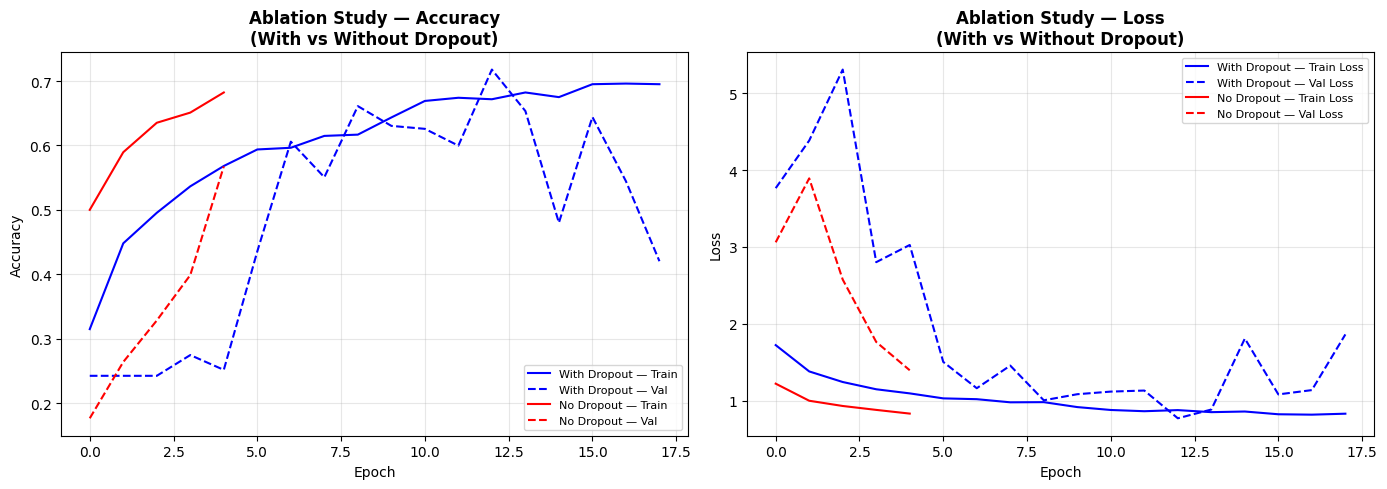

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(history_adam.history['train_accuracy'] if 'train_accuracy' in history_adam.history else history_adam.history['accuracy'],
             label='With Dropout — Train', color='blue')
axes[0].plot(history_adam.history['val_accuracy'],
             label='With Dropout — Val', color='blue', linestyle='--')
axes[0].plot(history_no_dropout.history['accuracy'],
             label='No Dropout — Train', color='red')
axes[0].plot(history_no_dropout.history['val_accuracy'],
             label='No Dropout — Val', color='red', linestyle='--')
axes[0].set_title('Ablation Study — Accuracy\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(history_adam.history['loss'],
             label='With Dropout — Train Loss', color='blue')
axes[1].plot(history_adam.history['val_loss'],
             label='With Dropout — Val Loss', color='blue', linestyle='--')
axes[1].plot(history_no_dropout.history['loss'],
             label='No Dropout — Train Loss', color='red')
axes[1].plot(history_no_dropout.history['val_loss'],
             label='No Dropout — Val Loss', color='red', linestyle='--')
axes[1].set_title('Ablation Study — Loss\n(With vs Without Dropout)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches='tight')
plt.show()


From the above graph we can tell that Dropout plays a crucial role in this model. Without Dropout, the model trained very quickly in the first five epoch buth triggered EarlyStopping due to the unstable validation loss, indicating overfitting.

In [ ]:
# Evaluate all models on test set
test_generator.reset()
loss_baseline, acc_baseline     = baseline_model.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_adam, acc_adam             = model_adam.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_sgd, acc_sgd               = model_sgd.evaluate(test_generator, verbose=0)
test_generator.reset()
loss_no_drop, acc_no_drop       = model_no_dropout.evaluate(test_generator, verbose=0)

print("=" * 70)
print(f"{'Model':<25} {'Test Acc':>10} {'Test Loss':>12} {'Train Time(s)':>15}")
print("=" * 70)
print(f"{'Baseline CNN':<25} {acc_baseline*100:>9.2f}% {loss_baseline:>12.4f} {baseline_training_time:>15.2f}")
print(f"{'Deeper + Adam':<25} {acc_adam*100:>9.2f}% {loss_adam:>12.4f} {time_adam:>15.2f}")
print(f"{'Deeper + SGD':<25} {acc_sgd*100:>9.2f}% {loss_sgd:>12.4f} {time_sgd:>15.2f}")
print(f"{'Deeper (No Dropout)':<25} {acc_no_drop*100:>9.2f}% {loss_no_drop:>12.4f} {time_ablation:>15.2f}")
print("=" * 70)

Model                       Test Acc    Test Loss   Train Time(s)
Baseline CNN                  74.01%       0.7146         2831.35
Deeper + Adam                 70.95%       0.7597         6052.26
Deeper + SGD                  24.31%       1.6643         1669.88
Deeper (No Dropout)           17.58%       3.0546         1634.78


##Classification Report

In [ ]:
test_generator.reset()
predictions      = model_adam.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print("Classification Report — Deeper Model (Adam):")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 800ms/step
Classification Report — Deeper Model (Adam):
              precision    recall  f1-score   support

       daisy       0.93      0.58      0.72       115
   dandelion       0.69      0.86      0.77       159
        rose       0.59      0.72      0.65       122
   sunflower       0.71      0.87      0.78       110
       tulip       0.76      0.52      0.62       148

    accuracy                           0.71       654
   macro avg       0.74      0.71      0.71       654
weighted avg       0.73      0.71      0.70       654



##Confusion Matrix

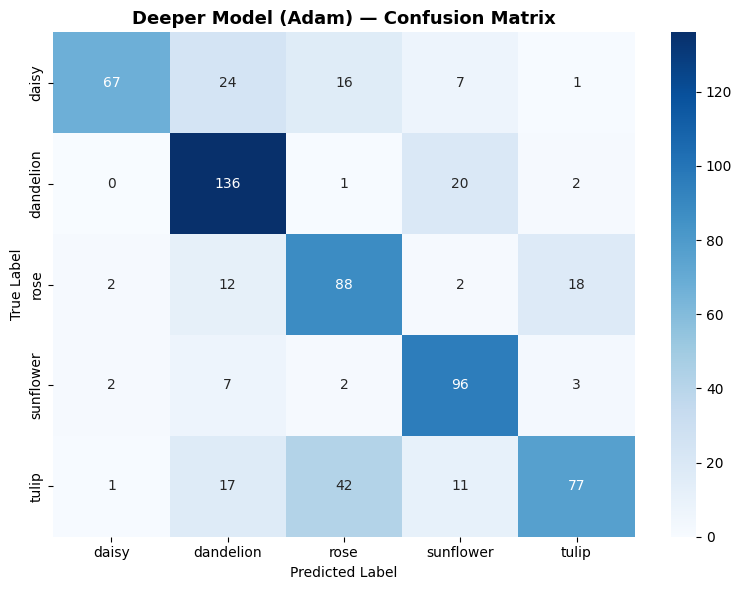

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper Model (Adam) — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("deeper_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


##Summary Table - Baseline vs Deeper

In [ ]:
print("=" * 60)
print("  Challenges and Observations Summary")
print("=" * 60)
print(f"  Hardware Used        : Google Colab (GPU)")
print(f"  Baseline Train Time  : {baseline_training_time:.2f} seconds")
print(f"  Deeper (Adam) Time   : {time_adam:.2f} seconds")
print(f"  Deeper (SGD) Time    : {time_sgd:.2f} seconds")
print(f"  Ablation Time        : {time_ablation:.2f} seconds")
print("=" * 60)
print("\n  Key Observations:")
print("  - Deeper model takes longer to train due to more layers")
print("  - Adam converges faster than SGD")
print("  - Dropout reduces overfitting (train/val gap is smaller)")
print("  - Model without Dropout shows higher train acc but lower val acc")
print("=" * 60)

  Challenges and Observations Summary
  Hardware Used        : Google Colab (GPU)
  Baseline Train Time  : 2831.35 seconds
  Deeper (Adam) Time   : 6052.26 seconds
  Deeper (SGD) Time    : 1669.88 seconds
  Ablation Time        : 1634.78 seconds

  Key Observations:
  - Deeper model takes longer to train due to more layers
  - Adam converges faster than SGD
  - Dropout reduces overfitting (train/val gap is smaller)
  - Model without Dropout shows higher train acc but lower val acc


**Key Obverations overall:**

####-Deeper model take longer time to train as compare to baseline due to the more layers.
####-Adam train better than the SGD
####-Model without dropout shows higher train acc but lower val acc
####-Dropout have significant role to reduce the overfitting


##Save the Deeper Model

In [ ]:
model_adam.save("deeper_model_adam.h5")
model_sgd.save("deeper_model_sgd.h5")
print("Both models saved successfully!")

Both models saved successfully!


# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

In [ ]:
import os

# load dataset path
original_dir = "/content/drive/MyDrive/AI and ML/coursework/flowers"
base_dir     = "/content/drive/MyDrive/AI and ML/coursework/split_data"
train_dir    = os.path.join(base_dir, "train")
val_dir      = os.path.join(base_dir, "val")
test_dir     = os.path.join(base_dir, "test")

#
IMG_SIZE   = (224, 224) # Changed to (224, 224) for VGG16 input requirements
BATCH_SIZE = 32
NUM_CLASSES = 5

print(f"Image size set to {IMG_SIZE} to match VGG16 input requirements")

Image size set to (224, 224) to match VGG16 input requirements


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os # Added import os for directory checks

# Check if train_dir exists. If not, prompt the user to run the data splitting cell.
if not os.path.exists(train_dir):
    print(f"Error: The directory '{train_dir}' was not found. Please ensure you have run cell 'f_WJqaiG1cx1' to perform the data splitting before executing this cell.")
    raise FileNotFoundError(f"Directory not found: {train_dir}. Please run data splitting cell 'f_WJqaiG1cx1'.")

# ── Training Generator: Augmentation + VGG16 Preprocessing ──
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # VGG16 specific normalization
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ── Val & Test: VGG16 Preprocessing ONLY ──
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices : {train_generator.class_indices}")
print(f"   Train batches : {len(train_generator)}")
print(f"   Val   batches : {len(val_generator)}")
print(f"   Test  batches : {len(test_generator)}")

Found 3040 images belonging to 5 classes.
Found 652 images belonging to 5 classes.
Found 654 images belonging to 5 classes.

Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}
   Train batches : 95
   Val   batches : 21
   Test  batches : 21


##Create Data Genreators

We create new generators with 224x224 image size to match VGG16 input requirements.

##Load VGG16 Pre-Trained Model



In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
# Load VGG16 without the top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print(" VGG16 loaded successfully!")
print(f"   Total layers in VGG16: {len(base_model.layers)}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 VGG16 loaded successfully!
   Total layers in VGG16: 19


##Freeze All Base Layers - Feature Extraction

In [ ]:
# Freeze ALL layers of VGG16
for layer in base_model.layers:
    layer.trainable = False

# Verify frozen layers
print(f"Total layers     : {len(base_model.layers)}")
print(f"Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Frozen layers    : {sum(1 for l in base_model.layers if not l.trainable)}")

Total layers     : 19
Trainable layers : 0
Frozen layers    : 19


##Add the Custom layers for Flower Classification

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Add custom layers on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)          # Reduce spatial dimensions
x = Dense(256, activation='relu')(x)     # Fully connected layer
x = Dropout(0.5)(x)                      # Regularization
output = Dense(NUM_CLASSES, activation='softmax')(x)  # 5 flower classes

# Create the final model
model_tl = Model(inputs=base_model.input, outputs=output)

print("Custom model created!")
print(f"   Total layers     : {len(model_tl.layers)}")
print(f"   Trainable layers : {sum(1 for l in model_tl.layers if l.trainable)}")
print(f"   Frozen layers    : {sum(1 for l in model_tl.layers if not l.trainable)}")

Custom model created!
   Total layers     : 23
   Trainable layers : 4
   Frozen layers    : 19


In [ ]:
model_tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

##Compile and Train - 1. Feature Extraction

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time

# Compile
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training Strategy 1: Feature Extraction...")
start_fe = time.time()

history_fe = model_tl.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

time_fe = time.time() - start_fe
print(f"\n Feature Extraction Training Time: {time_fe:.2f} seconds")

Training Strategy 1: Feature Extraction...
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 87s 750ms/step - accuracy: 0.6145 - loss: 1.9455 - val_accuracy: 0.8267 - val_loss: 0.5823
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 64s 671ms/step - accuracy: 0.7622 - loss: 0.6522 - val_accuracy: 0.8420 - val_loss: 0.4793
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 648ms/step - accuracy: 0.7934 - loss: 0.5698 - val_accuracy: 0.8574 - val_loss: 0.4625
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 659ms/step - accuracy: 0.8092 - loss: 0.5195 - val_accuracy: 0.8574 - val_loss: 0.4337
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 638ms/step - accuracy: 0.8395 - loss: 0.4723 - val_accuracy: 0.8604 - val_loss: 0.4407
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 650ms/step - accuracy: 0.8457 - loss: 0.4274 - val_accuracy: 0.8681 - val_loss: 0.4317
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 65s 684ms/step - accuracy: 0.8582 - loss: 0.3856 - val_accuracy: 0.8742 - val_loss: 0.4187
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 651ms/step -

##Plot Training Curves - Feature Extraction

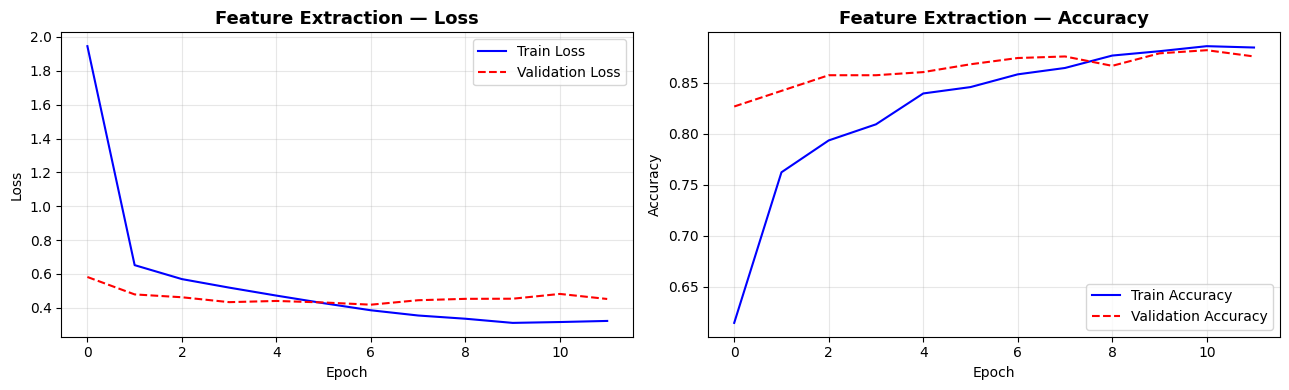

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_fe.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_fe.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
axes[0].set_title('Feature Extraction — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_fe.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history_fe.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[1].set_title('Feature Extraction — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feature_extraction_curves.png", dpi=150, bbox_inches='tight')
plt.show()

##Evaluate - Feature Extraction

In [ ]:
loss_tl, acc_tl = model_tl.evaluate(test_generator, verbose=0)

print("\n" + "=" * 45)
print("  Strategy 1: Feature Extraction Results")
print("=" * 45)
print(f"  Test Loss     : {loss_tl:.4f}")
print(f"  Test Accuracy : {acc_tl * 100:.2f}%")
print("=" * 45)


  Strategy 1: Feature Extraction Results
  Test Loss     : 0.4534
  Test Accuracy : 85.02%


##2. Fine Tuning

In [ ]:
for layer in model_tl.layers:
    layer.trainable = False       # freeze all first

for layer in model_tl.layers[-2:]:  # unfreeze last 4
    layer.trainable = True

# Verify
print(f"Total layers     : {len(model_tl.layers)}")
print(f"Trainable layers : {sum(1 for l in model_tl.layers if l.trainable)}")
print(f"Frozen layers    : {sum(1 for l in model_tl.layers if not l.trainable)}")

# Print which layers are trainable
print("\nTrainable layer names:")
for layer in model_tl.layers:
    if layer.trainable:
        print(f" {layer.name}")

Total layers     : 23
Trainable layers : 2
Frozen layers    : 21

Trainable layer names:
 dropout_1
 dense_3


In [ ]:
# Recompile with VERY LOW learning rate
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),   # 10x lower than feature extraction
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training Strategy 2: Fine Tuning...")
start_ft = time.time()

history_ft = model_tl.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stopping_ft]
)

time_ft = time.time() - start_ft
print(f"\n Fine Tuning Training Time: {time_ft:.2f} seconds")

Training Strategy 2: Fine Tuning...
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 65s 659ms/step - accuracy: 0.9069 - loss: 0.2611 - val_accuracy: 0.8696 - val_loss: 0.4320
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 641ms/step - accuracy: 0.9059 - loss: 0.2654 - val_accuracy: 0.8712 - val_loss: 0.4344
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 642ms/step - accuracy: 0.9039 - loss: 0.2623 - val_accuracy: 0.8681 - val_loss: 0.4336
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 640ms/step - accuracy: 0.9003 - loss: 0.2788 - val_accuracy: 0.8696 - val_loss: 0.4356
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 637ms/step - accuracy: 0.8993 - loss: 0.2677 - val_accuracy: 0.8712 - val_loss: 0.4352
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 646ms/step - accuracy: 0.8951 - loss: 0.2794 - val_accuracy: 0.8712 - val_loss: 0.4386

 Fine Tuning Training Time: 392.78 seconds


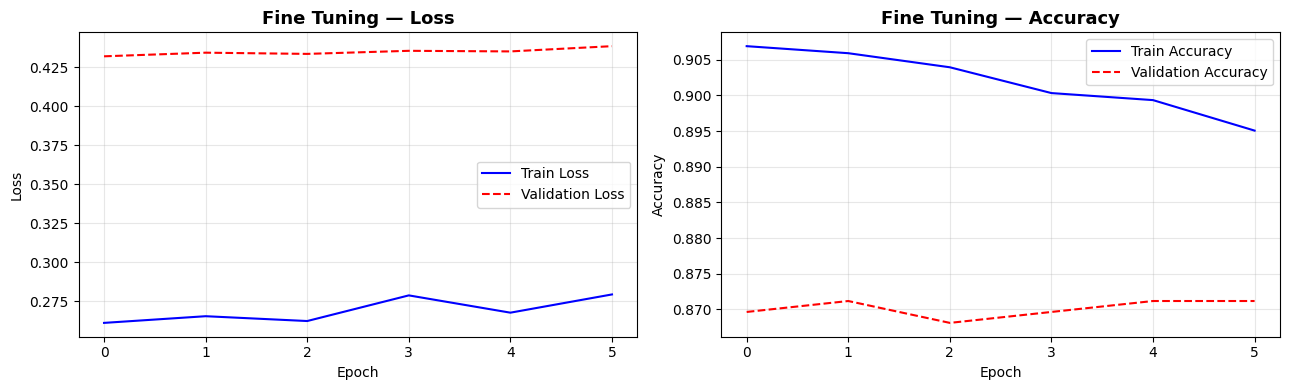

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_ft.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_ft.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
axes[0].set_title('Fine Tuning — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_ft.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history_ft.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
axes[1].set_title('Fine Tuning — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fine_tuning_curves.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
loss_ft, acc_ft = model_tl.evaluate(test_generator, verbose=0)

print("\n" + "=" * 45)
print("  Strategy 2: Fine Tuning Results")
print("=" * 45)
print(f"  Test Loss     : {loss_ft:.4f}")
print(f"  Test Accuracy : {acc_ft * 100:.2f}%")
print("=" * 45)


  Strategy 2: Fine Tuning Results
  Test Loss     : 0.4611
  Test Accuracy : 85.78%


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Reset before predicting
test_generator.reset()

predictions      = model_tl.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = test_generator.classes
class_names      = list(test_generator.class_indices.keys())

print(f"Predictions : {len(predicted_labels)}")
print(f"True labels : {len(true_labels)}")

print("\nClassification Report:")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                             target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step
Predictions : 654
True labels : 654

Classification Report:
              precision    recall  f1-score   support

       daisy       0.87      0.90      0.88       115
   dandelion       0.87      0.89      0.88       159
        rose       0.82      0.83      0.82       122
   sunflower       0.88      0.86      0.87       110
       tulip       0.85      0.82      0.83       148

    accuracy                           0.86       654
   macro avg       0.86      0.86      0.86       654
weighted avg       0.86      0.86      0.86       654



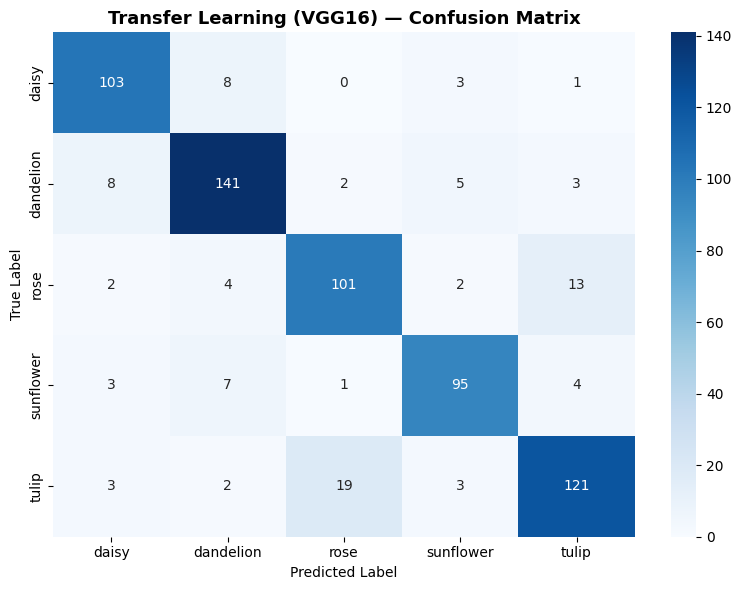

 Confusion matrix saved.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning (VGG16) — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("transfer_learning_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved.")

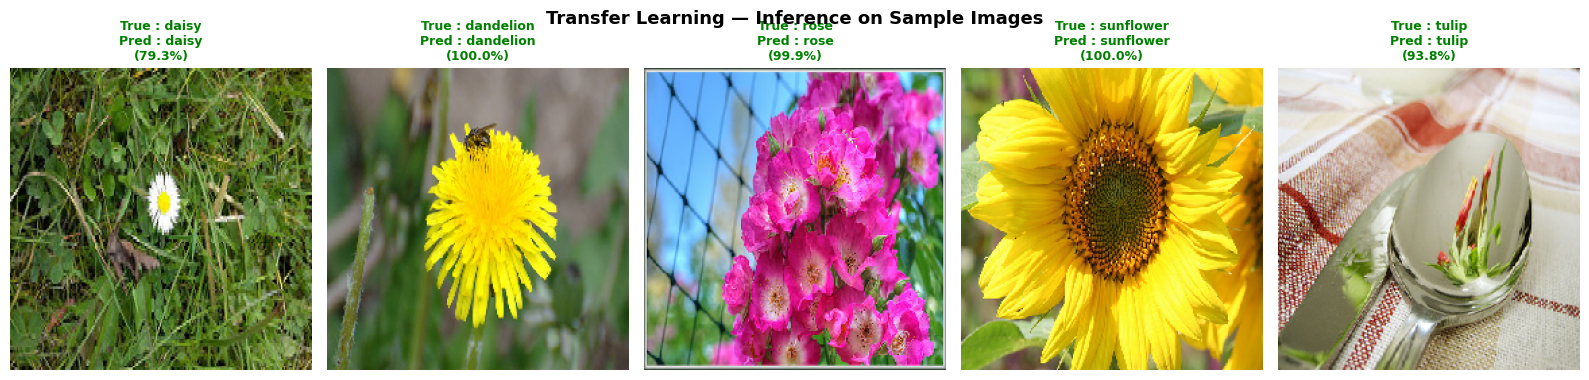


 Green = Correct   |   Red = Wrong


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Pick one image from each class
sample_images = []
sample_labels = []

for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    img_name   = random.choice(os.listdir(class_path))
    sample_images.append(os.path.join(class_path, img_name))
    sample_labels.append(class_name)

# Plot predictions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Transfer Learning — Inference on Sample Images",
             fontsize=13, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(sample_images, sample_labels)):
    img     = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = keras_image.img_to_array(img)
    img_arr = preprocess_input(img_arr)         # VGG16 preprocessing
    img_arr = np.expand_dims(img_arr, axis=0)

    pred       = model_tl.predict(img_arr, verbose=0)
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    axes[i].imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    axes[i].axis('off')
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )

plt.tight_layout()
plt.savefig("transfer_learning_inference.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Green = Correct   |   Red = Wrong")

In [ ]:
# ── Summary Table ──
print("=" * 65)
print(f"{'Model':<30} {'Test Accuracy':>15} {'Test Loss':>12}")
print("=" * 65)
print(f"{'Baseline CNN (Scratch)':<30} {baseline_test_acc*100:>14.2f}% {baseline_test_loss:>12.4f}")
print(f"{'Deeper CNN + Adam':<30} {acc_adam*100:>14.2f}% {loss_adam:>12.4f}")
print(f"{'VGG16 Feature Extraction':<30} {acc_fe*100:>14.2f}% {loss_fe:>12.4f}")
print(f"{'VGG16 Fine Tuning':<30} {acc_ft*100:>14.2f}% {loss_ft:>12.4f}")
print("=" * 65)

Model                            Test Accuracy    Test Loss


NameError: name 'baseline_test_acc' is not defined

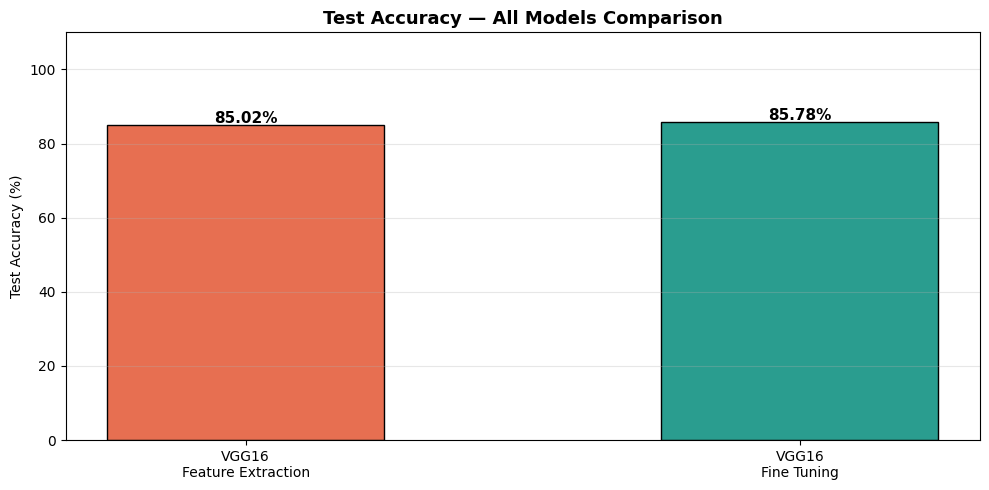

In [ ]:
# ── Bar Chart Comparison ──
models      = ['VGG16\nFeature Extraction', 'VGG16\nFine Tuning']
accuracies  = [acc_tl*100, acc_ft*100]
colors      = ['#e76f51', '#2a9d8f']

plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{acc:.2f}%",
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title("Test Accuracy — All Models Comparison", fontsize=13, fontweight='bold')
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("all_models_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_tl.save("vgg16_transfer_learning.h5")
print("Transfer learning model saved as vgg16_transfer_learning.h5")